# Exploratory Data Analysis

## Descripción General

En este documento buscámos entender los datos que tenemos a nuestra disposición, para predecir que clientes se subscribirán a un déposito a plazos. Queremos entender la estructura del dataset y la calidad de los datos para prepararnos para el pre-procesado.

In [30]:
!pip install jinja2 xgboost joblib pandas numpy matplotlib scikit-learn -q

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

def nl():
    print('\n')


# Helper function to format tables
def show_df(df, precision=2, width="100%", percent_cols=None):
    styler = (
        df.style
        .format(precision=precision, na_rep="NaN")
        .set_table_attributes(f'style="width:{width}"')
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("text-align", "left"), ("padding", "6px 10px")]},
        ])
        .hide(axis="index")
    )

    if percent_cols:
        styler = styler.format({c: "{:.2f}%" for c in percent_cols})

    display(styler)


print("Datasets:")
!ls ../data


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Datasets:
bank_14.pkl             bank_competition_14.pkl


Podemos observar que tenemos dos datasets, `bank_14.pkl` lo usaremos para entrenar y `bank_competition_14.pkl` para probar.

## Carga de Data y Visión Géneral

El objetivo ahora es entender la estructura géneral de los datos y tener una idea inicial de la forma de nuestros datasets.

In [2]:
df_train = pd.read_pickle('../data/bank_14.pkl')
df_test = pd.read_pickle('../data/bank_competition_14.pkl')

nl()
print('Tamaño de train: ', str(df_train.shape))
print('Tamaño de test: ', str(df_test.shape))
print('Columnas: ', str(df_train.columns.values.tolist()))



Tamaño de train:  (11000, 17)
Tamaño de test:  (162, 16)
Columnas:  ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


La variable objetivo es `deposit`. Podemos observar que hay 16 features aparte de nuestro objetivo, tenemos 11000 datos de entrenamiento y 162 para hacer testing. Más adelante exploraremos todas las variables a mayor detalle.

## Análisis de la Variable Objetivo

Empecemos por observar la distribución de los datos.

object


Class,Count,Percentage
no,5780,52.55
yes,5220,47.45


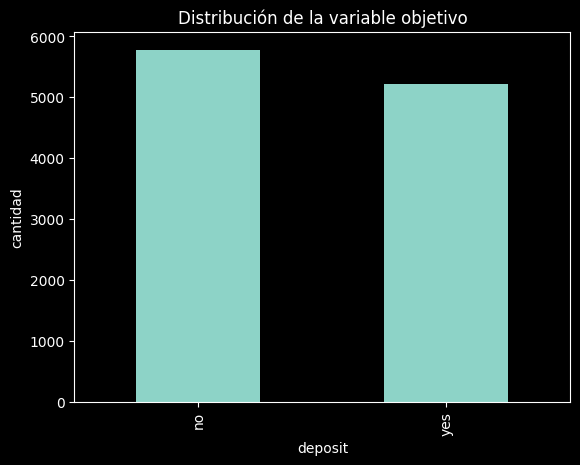

In [3]:
target = df_train['deposit'].tolist()

print(df_train['deposit'].dtype)


def label_plot(title, x, y):
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)


summary = pd.DataFrame({
    "Class": df_train['deposit'].value_counts().index,
    "Count": df_train['deposit'].value_counts().values,
    "Percentage": df_train['deposit'].value_counts(normalize=True).values * 100
})

show_df(summary)

df_train["deposit"].value_counts().plot(kind="bar")
label_plot('Distribución de la variable objetivo', 'deposit', 'cantidad')
plt.show()

La variable `deposit` presenta dos clases "yes" y "no", por lo que el problema es de clasificación binaria. La clase mayoritaria es "no", representando 52.54% de las instancias, mientras que "yes" representa el 47.45%. Por tanto, el conjunto de datos presenta un desbalance leve, que tendrá que tomarse en cuenta durante la evaluación de modelos.

## Esquema de Variables


In [4]:
summary = pd.DataFrame({
    "Feature": df_train.columns,
    "Semantic Type": df_train.dtypes,
    "Unique Values": df_train.nunique(dropna=True).tolist(),

})

summary = summary.sort_values("Semantic Type")

show_df(summary)

n = len(df_train)

constant_cols = df_train.columns[df_train.nunique() <= 1].tolist()
id_cols = df_train.columns[df_train.nunique() == n].tolist()

print("Constant columns:", constant_cols if constant_cols else "None")
print("Potential ID columns:", id_cols if id_cols else "None")

Feature,Semantic Type,Unique Values
age,int64,76
previous,int64,34
pdays,int64,472
campaign,int64,36
duration,int64,1423
balance,int64,3783
day,int64,31
month,object,12
contact,object,3
loan,object,2


Constant columns: None
Potential ID columns: None


Quitando deposit, tengo 16 features. 7 son números, 11 son variables de tipo object. Las variables object tienen pocos valores únicos, lo que me hace pensar que son categóricas. No hay ninguna variable constante ni de ID.

Procederé a analizarlas a mayor detalle, buscando entender como se distribuyen y en cuáles vale la pena indagar más a profundidad después.


### Variables Categóricas

Nos interesa saber su cardinalidad, si hay desbalances en las distribuciones, cúal es la categória dominante y si les faltan valores.

In [5]:
cat = df_train.select_dtypes(include="object")

rows = []

for col in cat.columns:
    freq = (cat[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    categories = ["NaN" if pd.isna(x) else x for x in freq.index]
    dist = [f"({catg}, {pct}%)" for catg, pct in zip(categories, freq.tolist())]

    rows.append(", ".join(dist))

summary = pd.DataFrame({
    "Feature": cat.columns,
    "n_categories": cat.nunique(dropna=True).tolist(),
    "missing_values": cat.isnull().sum().tolist(),
    "missing_values %": (cat.isnull().mean() * 100).round(2).values,
    "category_distribution_top": rows,
})

summary = summary.sort_values("n_categories", ascending=False)

show_df(summary)

Feature,n_categories,missing_values,missing_values %,category_distribution_top
job,12,174,1.58,"(management, 22.52%), (blue-collar, 17.27%), (technician, 15.97%), (admin., 11.75%), (services, 8.27%), (retired, 6.82%), (self-employed, 3.59%), (student, 3.22%), (unemployed, 3.08%), (entrepreneur, 2.88%), (housemaid, 2.45%), (NaN, 1.58%), (unknown, 0.6%)"
month,12,0,0.00,"(may, 25.27%), (aug, 13.64%), (jul, 13.59%), (jun, 10.95%), (nov, 8.45%), (apr, 8.23%), (feb, 6.94%), (oct, 3.52%), (jan, 3.11%), (sep, 2.85%), (mar, 2.46%), (dec, 0.99%)"
education,4,0,0.00,"(secondary, 49.03%), (tertiary, 33.0%), (primary, 13.48%), (unknown, 4.49%)"
poutcome,4,0,0.00,"(unknown, 74.59%), (failure, 10.98%), (success, 9.63%), (other, 4.8%)"
marital,3,340,3.09,"(married, 55.26%), (single, 30.39%), (divorced, 11.25%), (NaN, 3.09%)"
contact,3,0,0.00,"(cellular, 72.02%), (unknown, 20.99%), (telephone, 6.99%)"
default,2,0,0.00,"(no, 98.48%), (yes, 1.52%)"
housing,2,0,0.00,"(no, 52.74%), (yes, 47.26%)"
loan,2,0,0.00,"(no, 86.99%), (yes, 13.01%)"
deposit,2,0,0.00,"(no, 52.55%), (yes, 47.45%)"


Observaciones:
* `default` tiene una distribución extremadamente concentrada en "no" (98.5%). Esto sugiere una baja variabilidad y potencialmente una utilidad predictiva limitada. No conviene eliminarla automáticamente, pero sí tener presente que aporta muy poca diversidad.
* `job` y `marital` tienen valores nulos: Las analizaremos a mayor profundidad para saber como tratarlas.
* `job`, `education`, `contact` y `poutcome` tienen "unknown" como clases. Hay que analizar su valor semántico par saber si tratarlos como información no disponible o un valor nulo, esa decir una categória o un missing imputable.
* `month` y `job` tienen 12 categorías diferentes, esto no es cardinalidad extrema, podemos hacer encoding categórico sin problema.
    * Aunque tengan valores con poca presencia, como "dec" en `month` y "housemaid" en `job`, no son suficientemente pequeños como para tener que agruparlos inmediatamente.

Cabe recalcar que `poutcome` está dominada por la categória "unknown" (74.6%), lo que nos indica que para la mayoría de observaciones no hay información concisa. Esto puede reducir su utilidad.

Basado en estos datos, clasificaría las variables de la siguiente manera:
* **Sin Incidencia Particular:** `housing`, `loan`
* **Variables Binarias Muy Desbalanceadas:** `default`
* **Variables Ambiguas ("unknown"):** `job`, `education`, `contact`, `poutcome`
* **Variables con Valores Nulos:** `job`, `marital`
* **Variables con Alta Cardinalidad:** `month`, `job`



### Variable Numéricas

Nos interesa saber la distribución de las variables, sus rangos y si tienen valores extremos.

In [6]:
num = df_train.select_dtypes(include="number")


def outlier_info_iqr(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": mask.sum(),
        "Outliers (%)": mask.mean() * 100
    }


summary = pd.DataFrame({
    "Feature": num.columns,
    "Min": [num[col].min() for col in num.columns],
    "Max": [num[col].max() for col in num.columns],
    "Range": [num[col].max() - num[col].min() for col in num.columns],
    "STD": [num[col].std() for col in num.columns],
    "Skewness": [num[col].skew() for col in num.columns],
    "Kurtosis": [num[col].kurtosis() for col in num.columns],
    "Mean": [num[col].mean() for col in num.columns],
    "Median": [num[col].median() for col in num.columns],
})

show_df(summary)

outlier_table = pd.DataFrame([
    {"Feature": col, **outlier_info_iqr(num[col])}
    for col in num.columns
])

show_df(outlier_table.sort_values("Outliers (%)", ascending=False))

Feature,Min,Max,Range,STD,Skewness,Kurtosis,Mean,Median
age,18,95,77,11.94,0.86,0.62,41.25,39.00
balance,-6847,81204,88051,3217.40,8.25,128.57,1529.14,549.50
day,1,31,30,8.42,0.11,-1.06,15.66,15.00
duration,2,3881,3879,347.52,2.14,7.29,372.52,255.00
campaign,1,63,62,2.72,5.57,57.87,2.51,2.00
pdays,-1,854,855,108.78,2.46,6.90,51.31,-1.00
previous,0,58,58,2.28,7.43,109.01,0.83,0.00


Feature,Q1,Q3,IQR,Lower bound,Upper bound,Outliers,Outliers (%)
pdays,-1.00,20.25,21.25,-32.88,52.12,2711,24.65
previous,0.00,1.00,1.00,-1.50,2.50,1234,11.22
balance,122.75,1711.00,1588.25,-2259.62,4093.38,1043,9.48
duration,138.00,498.00,360.00,-402.00,1038.00,620,5.64
campaign,1.00,3.00,2.00,-2.00,6.00,589,5.35
age,32.00,49.00,17.00,6.50,74.50,171,1.55
day,8.00,22.00,14.00,-13.00,43.00,0,0.00


Observaciones:
* Las variables numéricas no están en la misma escala. `balance` tiene un rango y desviación mayor que el resto. `campaign`, `previous` o `day` tienen escalas más reducidas. Esto sugiere que, si se utilizan modelos sensibles a distancias o magnitudes, será necesario aplicar escalado.
* `duration`, `balance`, `previous` y `campaign` muestran una asimetría positiva y una curtosis elevada.
    * En `previous` y `campaign` sugiere que la mayoría de observaciones se concentran en valores bajos.
    * `duration` presenta estas características de forma menos extrema que las otras. Aun así, la diferencia entre media y mediana y su porcentaje de outliers indican que conviene tenerla en cuenta como variable potencialmente problemática.
* `balance` es la variable numérica más extrema desde el punto de vista distributivo. Podemos observar una distribución sesgada a la derecha con presencia de valores altos poco frecuentes.
* `pdays` requiere una interpretación diferente. Esta variable no debe interpretarse como una numérica ordinaria, ya que contiene el valor -1, que actúa como código especial. Por tanto, parte de su comportamiento estadístico puede deberse a esa codificación.
* `age` muestra una distribución relativamente estable en comparación con el resto. Aunque presenta sesgo positivo y valores extremos según el IQR, de igual manera su comportamiento es mucho más moderado.
* `day` es la variable más regular del conjunto. Tiene asimetría baja, curtosis negativa y no presenta outliers, no parece plantear problemas a nivel distributivo.

Las variables que requieren mayor atención son `balance`, `previous`, `campaign`, `duration` y especialmente `pdays`, ya sea por su asimetría, por sus valores extremos o semántica especial. En cambio, `age` y `day` parecen menos problemáticas desde el punto de vista estructural.

## Correlación de Los Predictores con La Variable Objetivo

Después de haber hecho el barrido de las variables, nos conviene saber realmente que variables influencian la variable objetivo `deposit`.

### Variables Numéricas


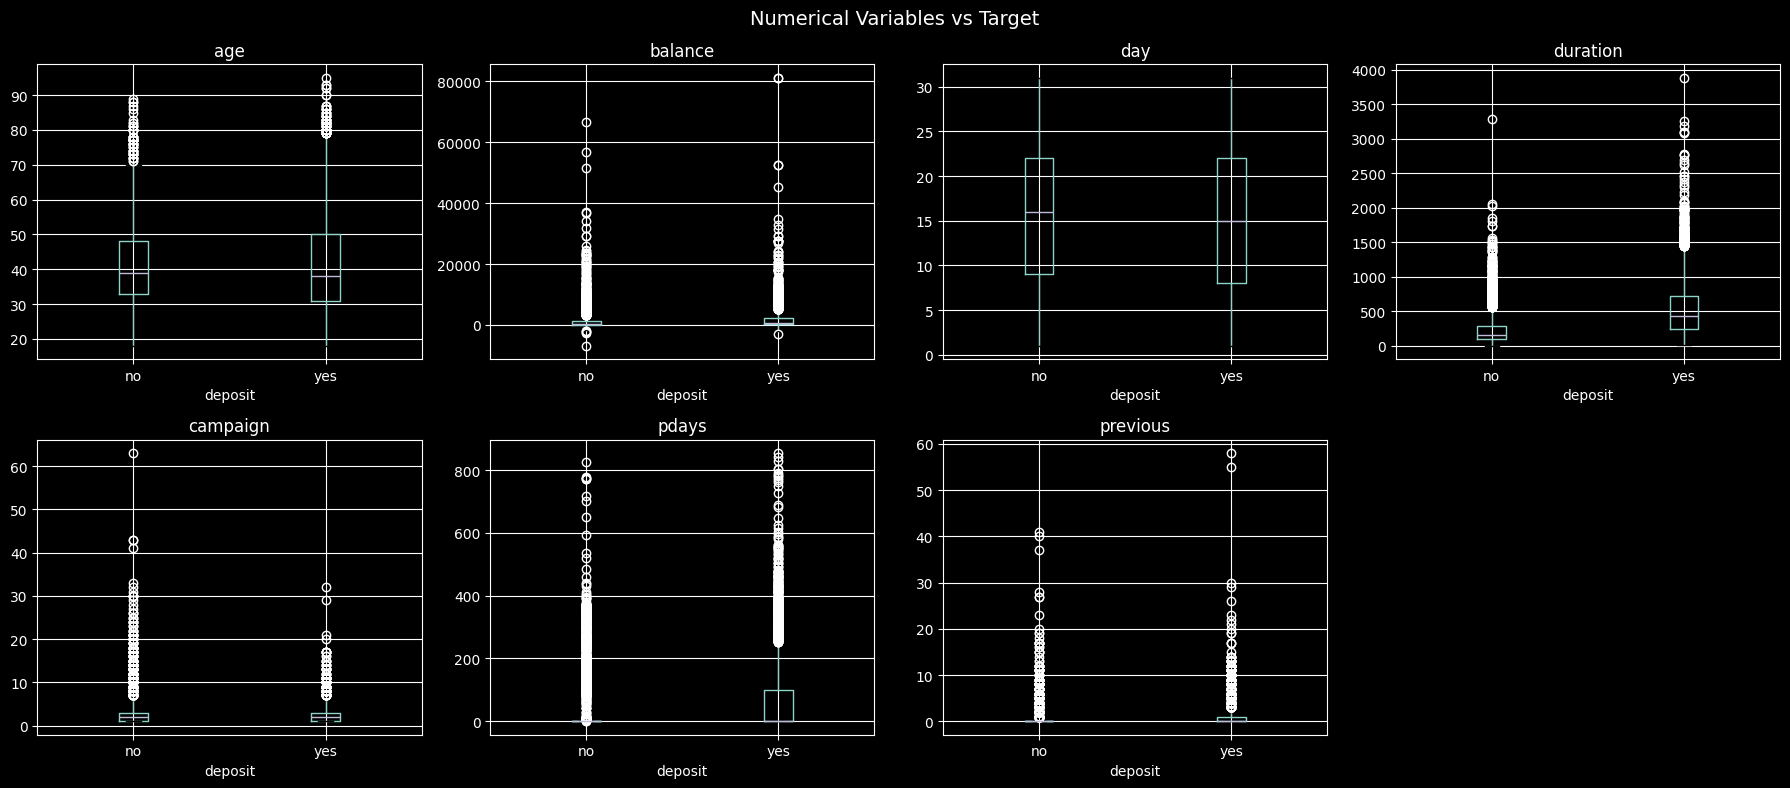

Feature,mean (no),mean (yes),difference (yes - no)
balance,1279.10,1806.00,526.90
duration,223.17,537.90,314.74
pdays,35.48,68.84,33.36
day,16.12,15.15,-0.98
age,40.85,41.70,0.85
campaign,2.84,2.14,-0.70
previous,0.52,1.17,0.65


In [7]:
num_cols = df_train.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df_train.boxplot(column=col, by="deposit", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("deposit")

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Variables vs Target", fontsize=14)
plt.tight_layout()
plt.show()

mean_by_class = df_train.groupby("deposit")[num_cols].mean().T
mean_by_class.columns = ["mean (no)", "mean (yes)"]
mean_by_class["difference (yes - no)"] = mean_by_class["mean (yes)"] - mean_by_class["mean (no)"]
mean_by_class["abs_diff"] = mean_by_class["difference (yes - no)"].abs()
mean_by_class = mean_by_class.sort_values("abs_diff", ascending=False).drop(columns="abs_diff")

show_df(mean_by_class.reset_index().rename(columns={"index": "Feature"}))

Observaciones:
* La variable más influyente es `duration` (confirmado en la tabla: media 538 vs. 223), los clientes que más se subscriben tienen llamadas más largas. Predictor fuerte.
* Los clientes "si" tienen un `balance` parcialmente mayor (1806 vs. 1279). Es una señal moderada, tiene muchos outliers.
* `age` las boxes están casi superpuestas y la diferencia es de 0.85 años, es básicamente inútil como predictor autónomo.
* `day` prácticamente idéntico, no es predictivo.
* `campaign` los clientes "no" fueron contactados más (2.84 vs. 2.14). Podemos interpretar que si tuviste que llamar a alguien múltiples veces, entonces no tenían interés.
* `pdays`, dominada por él -1, voy a tener que analizarla más a detalle.
* `previous`, dominada por el 0, la mayoría de clientes no fueron contactados antes de esta campaña.

### Variables Categóricas

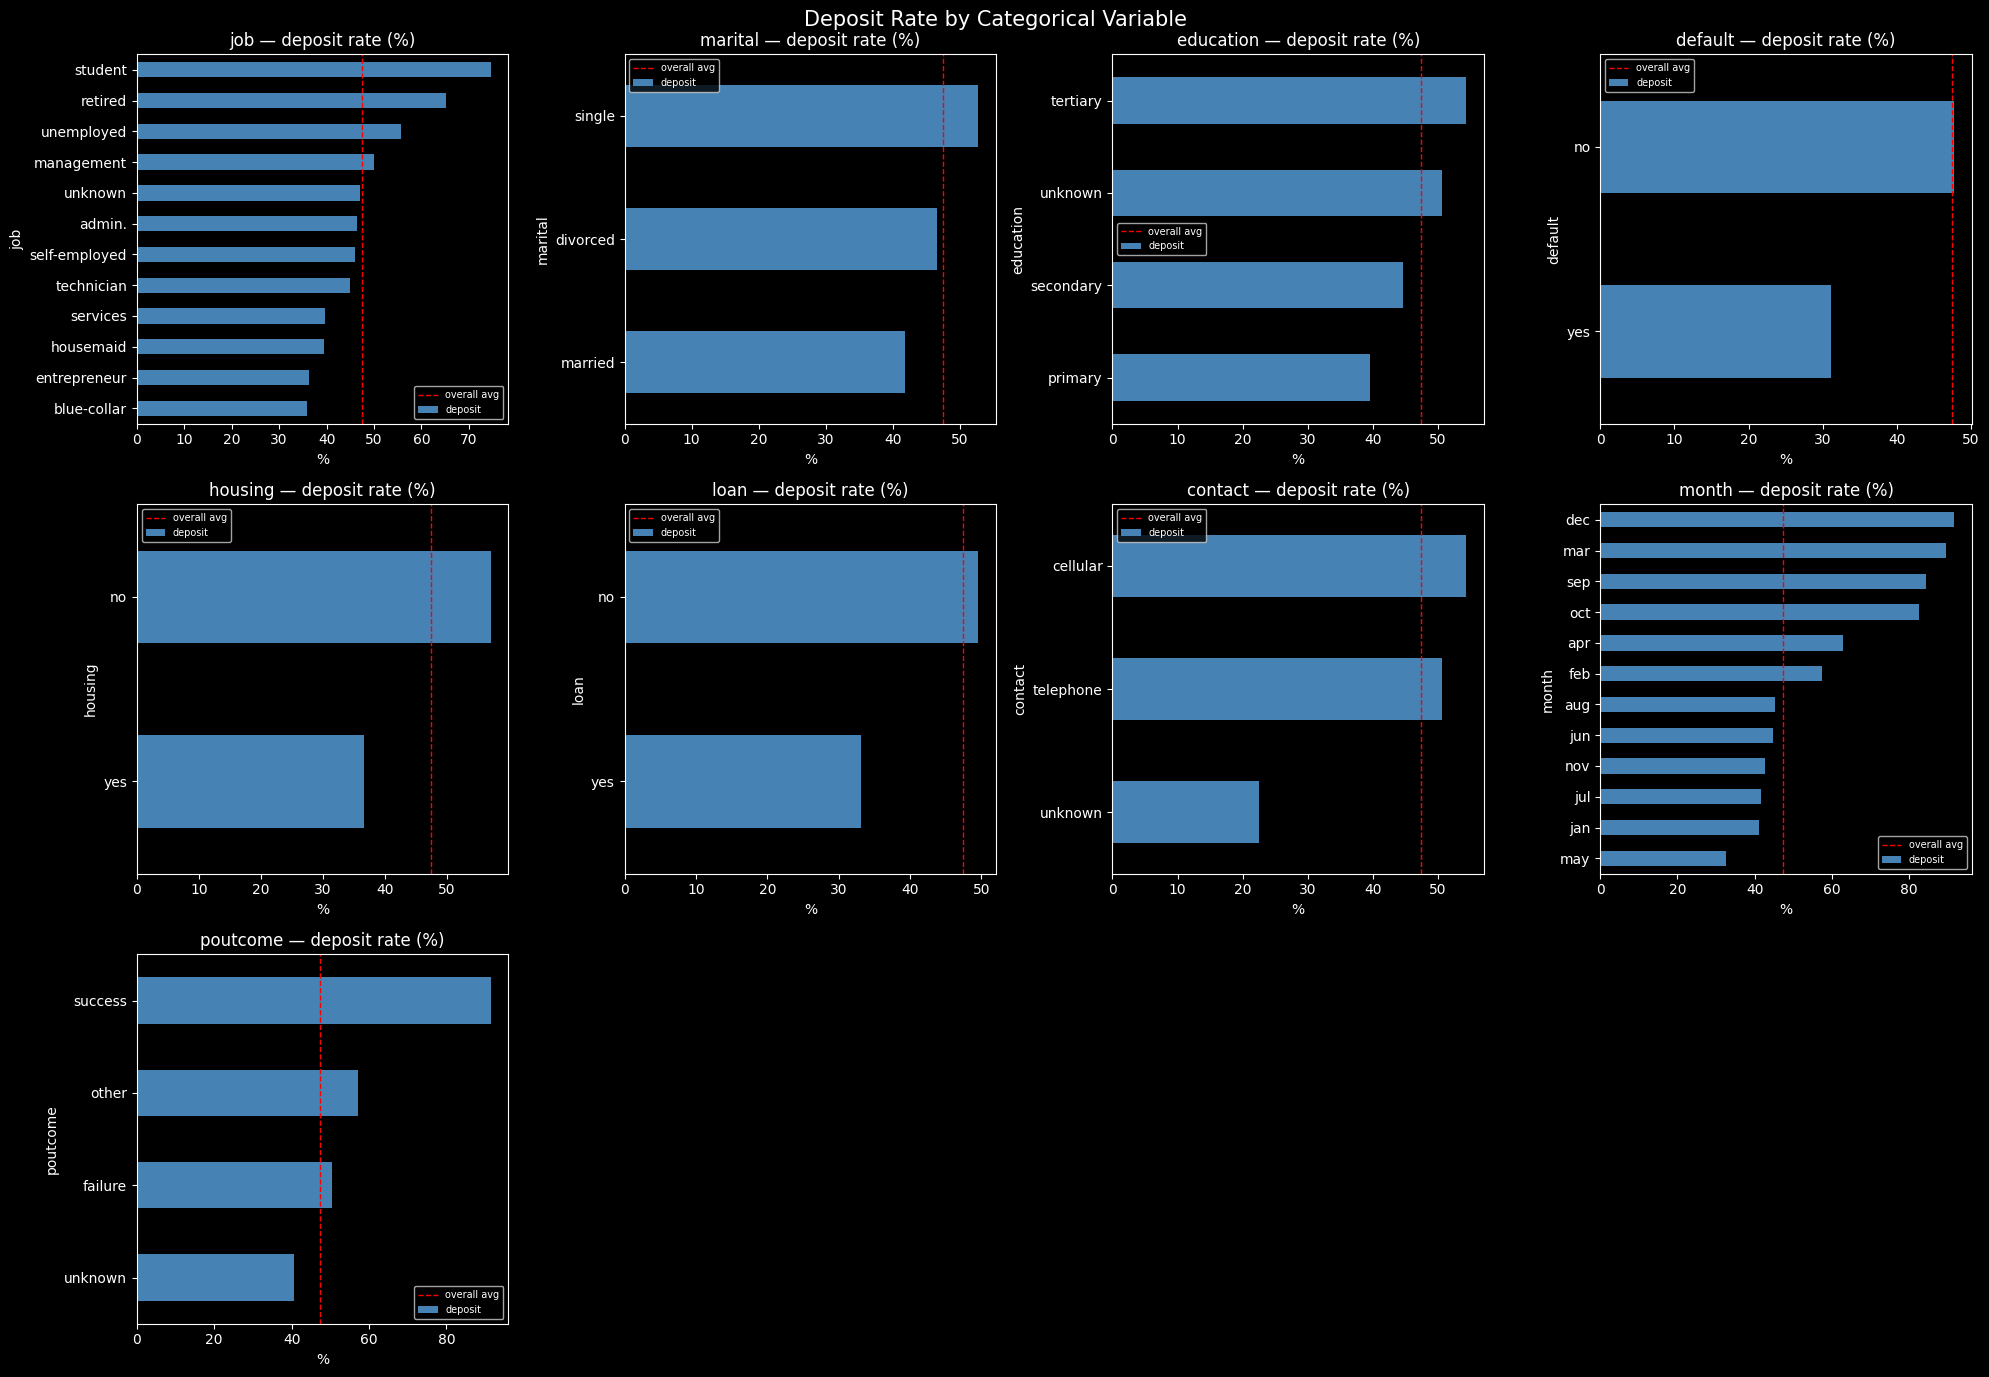

In [8]:
cat_cols = [c for c in df_train.select_dtypes(include="object").columns if c != "deposit"]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df_train.groupby(col)["deposit"].apply(lambda x: (x == "yes").mean() * 100).sort_values()
    rate.plot(kind="barh", ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} — deposit rate (%)")
    axes[i].set_xlabel("%")
    axes[i].axvline(x=(df_train["deposit"] == "yes").mean() * 100,
                    color="red", linestyle="--", linewidth=1, label="overall avg")
    axes[i].legend(fontsize=7)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Deposit Rate by Categorical Variable", fontsize=15)
plt.tight_layout()
plt.show()

Observaciones:
* `poutcome`, la variable más fuerte. El éxito de una campaña anterior predice la subscripción muy bien (~85%). Aunque 74% sea "unknown", la señal de las categorías conocidas es decisiva.
* `contact` es fuerte. La mayoría de los clientes que se subscriben usan un celular. Si son difíciles de contactar, y usamos un método "unknown", entonces probablemente no se subscriban.
* `mortage` da buena señal. Clientes sin hipoteca o sin casa se suelen subscribir más.
* `month` aunque diciembre de señales fuertes, hay que recordar que solo representa el 1% de los meses. En los meses más presentes (may, jul, aug, jun, nov) tenemos señales reales. Mayo es bastante bajo (~30%), y constituye 25% de la data, esto es un indicativo.
* `job`, estudiantes y retirados están por encima de la media, blue-collar por debajo. Son categorías significativas.
* `education` no tiene mucha diferencia entre sus clases, es un predictor marginal.
* `marital` y `loan`, tienen pocas diferencias, probablemente no sea útil.
* `default` es prácticamente constante, entonces no podemos sacar conclusiones reales.


De estas variables categóricas `poutcome`, `contact`, `housing` y `month` tienen la mayor relación con `deposit`. `job` tiene una relación más moderada. `marital`, `loan` y `default` parecen tener poco valor predictivo. Sin embargo, estás conclusiones se basan en distribuciones marginales, la importancia de cada variable la veremos en el modelado.


### Revisión de pdays

Never contacted before: 8203 (74.6%)
Contacted before: 2797 (25.4%)

For those contacted before:
count    2797.00
mean      204.72
std       122.40
min         1.00
25%        98.00
50%       182.00
75%       286.00
max       854.00
Name: pdays, dtype: float64

Deposit rate — contacted before: 67.3%
Deposit rate — NOT contacted before: 40.7%


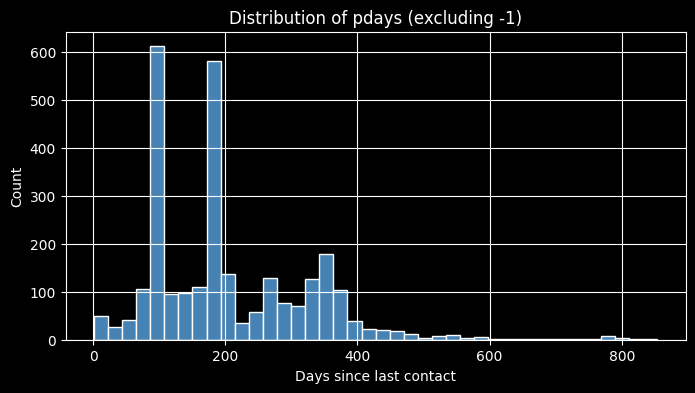

In [9]:
# pdays: -1 means "not contacted in previous campaign"
pdays_contacted = df_train[df_train["pdays"] != -1]["pdays"]
pdays_not_contacted = df_train[df_train["pdays"] == -1]

print(f"Never contacted before: {len(pdays_not_contacted)} ({len(pdays_not_contacted)/len(df_train)*100:.1f}%)")
print(f"Contacted before: {len(pdays_contacted)} ({len(pdays_contacted)/len(df_train)*100:.1f}%)")
print(f"\nFor those contacted before:")
print(pdays_contacted.describe().round(2))

# Deposit rate split: contacted vs not contacted before
rate_contacted = (df_train[df_train["pdays"] != -1]["deposit"] == "yes").mean() * 100
rate_not_contacted = (df_train[df_train["pdays"] == -1]["deposit"] == "yes").mean() * 100

print(f"\nDeposit rate — contacted before: {rate_contacted:.1f}%")
print(f"Deposit rate — NOT contacted before: {rate_not_contacted:.1f}%")

# Distribution of actual pdays values (excluding -1)
plt.figure(figsize=(8, 4))
pdays_contacted.hist(bins=40, color="steelblue", edgecolor="white")
plt.title("Distribution of pdays (excluding -1)")
plt.xlabel("Days since last contact")
plt.ylabel("Count")
plt.show()

En `pdays` él -1 representa usuarios que no fueron contactados en una campaña anterior, al quitarlo obtenemos unos datos interesantes. Podemos observar que en géneral usuarios que fueron contactados anteriormente suelen subscribirse más que usuarios que no fueron contactados anteriormente. Haber sido contactado en una campaña previa es uno de los indicativos más fuertes de nuestro dataset para la predicción. Esto tiene sentido intuitivo, si el banco ya tiene una relación contigo, eres más capaz de inscribirte a su plan de depósito.

Además, vemos algo curioso, el pico de días desde el último contacto son 100 y 180, esto nos muestra un poco como son los ciclos de campaña del banco, aunque no nos proporciona información relevante para el modelo. Solo un dato curioso.

Existen outliers, hay clientes que no se han contactado en ~850 días, pero esto no son errores, es data real.

## Conclusiones del EDA
Después de haber analizado la variable objetivo, la estructura y distribución de las variables, y su correlación con el objetivo, podemos extraer multiples conclusiones.

1. La variable objetivo `deposit` es de tipo categórica binaria, con dos clases "si" y "no", y está relativamente balanceada (47/~53). Esto nos indica que probablemente deberíamos usar `StratifiedKFold` para la cross-validation, así mantenemos el balance de las clases en los folds.

2. Nuestro mejor predictor numérico es `duration`, ya que tiene la mayor correlación con el éxito de subscripción por parte los usuarios. Esto tiene sentido, mientras más larga la llamada, más probable es que se inscriban.
    <br>&nbsp;&nbsp;Sin embargo, tenemos que tomar en cuenta que en un entorno real esta variable no se conoce antes de realizar la llamada. Podemos asumir que el caso práctico del banco es llamar a los clientes con más probabilidad de subscripción, pero en este caso la duración no existe.
    <br>&nbsp;&nbsp;Aun así, mantendremos la variable, ya que se usa para evaluar en la competencia y queremos hacer la mejor predicción, en un entorno laboral y no de competencia habría que hablar con el equipo y definir si se va a considerar esta variable o no.

3. `poutcome` es 74% "unknown". Sin embargo, cuando es "success" la tasa de subscripción es 85%. Esto nos muestra que "unknown" es una clase válida, si la tomamos como valor faltante y la imputamos con "success", "failure" u "other", dañamos la generalización.

4. La variable `default` es 98.5% "no". Probablemente, no vaya a ayudar a los modelos demasiado y puede ser un candidato de eliminación si el modelo sobre-ajusta, pero por ahora la mantengo.

## Implicaciones para El Pre-procesado

1. Manejo de `pdays`.
    * El problema: -1 es un código, no un número. Incluirlo confundiría modelos como KNN o Modelos Lineales porque -1 es cercano a 1 día, cuando en realidad tiene un valor semántico implícito.
    * La solución: Crear un transformador booleano. La trataríamos como una variable mixta.
        * Creamos un nuevo feature `pdays_contacted`. Es binario, 1 si `pdays != -1` sino 0.
        * Reemplazamos -1 con un valor neutro, como 0 o la media, después de crear el feature binario.
                * El problema con esto es que con 0 podemos interpretarlo como que lo venimos de contactar y la media puede asignar a personas que no hemos contactado la media. Entonces voy a usar un `FunctionTransformer` o un pipeline personalizado, ya que en KNN hay que imputar, pero en árboles no.

2. Encoding categórico:
    * One-Hot Encoding (OHE): Lo usamos para `marital`, `education`, `poutcome`, `contact`, `housing`, `loan` y `default`.
    * Alta Cardinalidad: Para `job` y `month`, OHE sigue funcionando (12 categorías cada uno), pero hay que asegurarnos de usar `handle_unknown='ignore'` en nuestro encoder para prevenir que falle si el test tiene "unknown".

3. Escalado Numérico:
    * Consideramos usar `RobustScaler`, ya que `balance`, `duration` y `campaign` tienen outliers pesados (como vimos en los box-plots), y este scaler los maneja mejor que `StandardScaler`. Este usa el mediano y el IQR, haciéndolo menos sensible a los extremos. De igual manera probaremos los otros scalers con CV para asegurarnos que escojamos el mejor.

4. Imputación:
    * Para `job` y `marital` (las únicas que tienen NaN) usaremos un `SimpleImputer(strategy='most_frequent')` o una constante (e.g. "missing").

Hay que tomar en cuenta que el EDA se realizó antes de hacer el holdout de train/test, por lo que estas decisiones pueden tener data leakage, así que antes de proceder con cambios drásticos, haremos comprobaciones con tests de scalers, árboles simples y otras tecnicas de visualización con modelos.

# Pre-Procesado

## Partición de Cross-Validation (CV)

Comó las clases de `deposit` están balanceadas (47-53), podríamos usar **Accuracy**, pero **ROC-AUC** tiene más sentido, esté mide que tan bien nuestro modelo categoriza positivos sobre negativos. El banco probablemente le interesa más saber que clientes dirán que sí.


In [10]:
# Initial config.
NIA_SEED = 100502359
np.random.seed(NIA_SEED)

# Holdout
X = df_train.drop('deposit', axis=1)
y = df_train['deposit'].map({'yes': 1, 'no': 0}) # Numeric mapping for ROC-AUC
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=NIA_SEED, stratify=y)

Ahora definimos las variables que vamos a usar en el pipeline.

In [12]:
num_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'pdays']
cat_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

## Scaling

Antes de empezar, veamos realmente cuál es el mejor scaler. Ya deduje que `RobustScaler` iba a ser el mejor, pero veámoslo rápidamente. Tomaré un valor de K para KNN y probaré tres scalers.

In [15]:
# pdays cleaner
def basic_cleaning(x_input):
    x_out = x_input.copy()

    # Binary flag
    x_out['was_contacted'] = (x_out['pdays'] != -1).astype(int)
    x_out['pdays'] = x_out['pdays'].replace(-1, 0)
    return x_out

# Using KNN with K=7
scalers = {'MinMax': MinMaxScaler(), 'Standard': StandardScaler(), 'Robust': RobustScaler()}
scaler_results = []

for name, s in scalers.items():
    # Temporal pipeline
    prep_temp = ColumnTransformer([
        ('num', s, num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_vars)
    ], remainder='passthrough')
    pipe_temp = Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', prep_temp),
        ('knn', KNeighborsClassifier(n_neighbors=7))
    ])
    # Using ROC-AUC
    scores = cross_val_score(pipe_temp, X_train, y_train, cv=5, scoring='roc_auc')
    scaler_results.append({'Scaler': name, 'ROC-AUC': scores.mean(), 'Std Dev': scores.std()})

summary = pd.DataFrame(scaler_results).sort_values(by='ROC-AUC', ascending=False)
summary['Stability (%)'] = (summary['Std Dev'] / summary['ROC-AUC']) * 100
show_df(summary)


Scaler,ROC-AUC,Std Dev,Stability (%)
Standard,0.88,0.01,0.76
Robust,0.86,0.01,0.85
MinMax,0.81,0.01,1.21


Podemos observar que `MinMaxScaler` tuvo el peor rendimiento, esto es de esperar, ya que es sensible a valores extremos y nuestra data tiene muchos.

Aunque las deducciones del EDA sugerían el uso de `RobustScaler` por la presencia de valores extremos, el resultado de la validación cruzada muestran que `StandardScaler` es superior. No solo obtiene un ROC-AUC mayor (0.88), sino que presenta mejor estabilidad (0.76%). Esto sugiere que los valores extremos en variables como 'duration' o 'balance' contienen información valiosa que `StandardScaler` preserva mejor.

Hagamos entonces un pipeline de pre-procesado.

In [18]:
# Machine for Numbers (Impute -> Scale)
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Machine for Words (Impute -> Encode)
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_vars),
    ('cat', cat_pipeline, cat_vars),
], remainder='passthrough')

# KNN y Árboles


## Árboles Poco Profundos

Usemos un árbol poco profundo (`max_depth=4`), tracémoslo y veamos las primeras decisiones que toma el modelo, para entender mejor nuestros datos.

In [ ]:
shallow_tree = Pipeline([
    ('clean', FunctionTransformer(basic_cleaning)),
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=4, random_state=NIA_SEED))
])

shallow_tree.fit(X_train, y_train)

# Get cat feature names from the OHE step
cat_feature_names = shallow_tree['prep'].named_transformers_['cat']['encode'].get_feature_names_out(cat_vars)

# Combine all feature names
feature_names = num_vars + list(cat_feature_names)

# Plot
plt.figure(figsize=(24, 8))
plot_tree(
    shallow_tree['clf'],
    feature_names=feature_names,
    class_names=['no', 'yes'],
    filled=False,
    rounded=True,
    fontsize=12
)
plt.title("Shallow Decision Tree (max_depth=4)")
plt.tight_layout()
plt.show()

El árbol confirma las conclusiones del EDA: `duration` es el predictor dominante y actúa como primera división. Para clientes con llamadas cortas, `poutcome_success` puede revertir la predicción, 189 clientes con llamadas cortas, pero campaña previa exitosa predicen como "yes". Esto sugiere que conviene mantener relaciones con los clientes. Este árbol es interpretable y valioso para el banco.

## Resultados por Omisión

Nos interesa saber que tan bien desempeña cada modelo con los valores predeterminados de sklearn. Para KNN es `n_neighbors=5` y para DecisionTree `max_depth=None`. Asi tendremos una base con la que comparar y sabremos de donde partimos.

In [23]:
def test_multiple(experiments):
    results = []
    for name, pipe in experiments.items():
        start = time.time()
        scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
        elapsed = time.time() - start
        results.append({
            'Config': name,
            'ROC-AUC': scores.mean(),
            'Std Dev': scores.std(),
            'Time (s)': round(elapsed, 2)
        })
    return results

fe_experiments = {
    'KNN (Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', KNeighborsClassifier())
    ]),
    'Tree (Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(random_state=NIA_SEED))
    ]),
    'Dummy (Most Frequent)': DummyClassifier(strategy='most_frequent'),
    'Dummy (Stratified)':    DummyClassifier(strategy='stratified', random_state=NIA_SEED),
}

fe_results = test_multiple(fe_experiments)

summary = pd.DataFrame(fe_results).sort_values(by='ROC-AUC', ascending=False)
show_df(summary)

Config,ROC-AUC,Std Dev,Time (s)
KNN (Base),0.87,0.01,0.15
Tree (Base),0.79,0.01,0.23
Dummy (Most Frequent),0.50,0.00,0.01
Dummy (Stratified),0.49,0.01,0.01


Podemos observar que los modelos estándar superan a los clasificadores Dummy (0.87 y 0.79 vs. 0.50 ROC-AUC), lo que confirma que ambos modelos están aprendiendo patrones del dataset y no simplemente explotando el desbalance de clases. Esto establece un umbral mínimo: cualquier modelo que no supere 0.50 ROC-AUC no tiene utilidad práctica.

## Optimización de Hiperparámetros

Ya con un margen de comparación definido, podemos probar diferentes hiperparámetros usando `GridSearch` para encontrar el modelo que mejor predice.

In [ ]:
def get_result(name, results):
    return next(r for r in results if r['Config'] == name)

def do_grid_search(pipe, grid, type="KNN"):
    start = time.time()
    search = GridSearchCV(pipe, grid, cv=5, scoring='roc_auc', n_jobs=-1)
    search.fit(X_train, y_train)
    elapsed = round(time.time() - start, 2)
    print(f"Best {type} params: {search.best_params_}")
    print(f"Best {type} ROC-AUC: {search.best_score_:.4f}")
    print(f"Time: {elapsed}s")
    best_idx = search.best_index_
    std = search.cv_results_['std_test_score'][best_idx]
    return search, elapsed, std

def simple_hpo(preprocessor, fe_results=None, search_spaces=None, cleaner=basic_cleaning, show_results=True):
    default_spaces = {
        'knn': {
            'clf__n_neighbors': [3, 5, 7, 11, 15, 17, 21],
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        },
        'tree': {
            'clf__max_depth': [3, 5, 7, 10, 15, None],
            'clf__min_samples_split': [2, 10, 20, 50, 75],
            'clf__min_samples_leaf': [1, 5, 10, 20],
            'clf__criterion': ['gini', 'entropy']
        }
    }
    spaces = {**default_spaces, **(search_spaces or {})}
    # KNN HPO
    knn_pipe = Pipeline([
        ('clean', FunctionTransformer(cleaner)),
        ('prep', preprocessor),
        ('clf', KNeighborsClassifier())
    ])
    knn_search, knn_time, knn_std = do_grid_search(knn_pipe, spaces['knn'], 'KNN')

    # Tree HPO
    tree_pipe = Pipeline([
        ('clean', FunctionTransformer(cleaner)),
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(random_state=NIA_SEED))
    ])

    tree_search, tree_time, tree_std = do_grid_search(tree_pipe, spaces['tree'], "Tree")

    if show_results:
        hpo_results = [
            {'Model': 'KNN (Base)', **{k: get_result('KNN (Base)', fe_results)[k] for k in ['ROC-AUC', 'Std Dev', 'Time (s)']}} if fe_results is not None else {},
            {'Model': 'KNN (Tuned)', 'ROC-AUC': knn_search.best_score_, 'Std Dev': knn_std, 'Time (s)': knn_time},
            {'Model': 'Tree (Base)', **{k: get_result('Tree (Base)', fe_results)[k] for k in ['ROC-AUC', 'Std Dev', 'Time (s)']}} if fe_results is not None else {},
            {'Model': 'Tree (Tuned)', 'ROC-AUC': tree_search.best_score_, 'Std Dev': tree_std, 'Time (s)': tree_time},
        ]
        hpo_results = [r for r in hpo_results if r] # Clean empoty dicts
        show_df(pd.DataFrame(hpo_results).sort_values('ROC-AUC', ascending=False))

    results = {
        'knn': [knn_search, knn_time, knn_std],
        'tree': [tree_search, tree_time, tree_std],
    }

    return results

simple_searches = simple_hpo(preprocessor, fe_results)

De este ajuste de hiperparámetros podemos observar lo siguiente:
* **KNN**: En este caso encontramos que `K=17` es el mejor parametro, lo que nos muestra que el modelo se beneficia de vecinos grandes y darle más peso a vecinos cercanos.
    * Obtuvimos una mejora ROC-AUC de 0.02 sobre `K=5` que es el estándar. Esta mejora es marginal y no justifica un costo computacional tan alto (~25x tiempo).
* **Árboles**: Los mejores parámetros son curiosos. `max_depth=None` significa que el arbol crece completamente, pero `min_samples_leaf=10` y `min_samples_split=75` hacen el trabajo de regularización, evitando separaciones en grupos muy pequeños. No es un arbol descontrolado, creció completamente, pero está bien podado.
    * La mejora ROC-AUC obtenida sobre el modelo estándar es significativa (0.11). Estos parámetros justifican el coste computacional.


In [ ]:
# ================= PLOTS ===================
def config_plot(axe, order, model, set_xticklabels, set_title, set_xlabel, set_ylabel='ROC-AUC', grid = True):
    order_len = range(len(order))
    axe.plot(order_len, model.values, marker='o')
    axe.set_xticks(order_len)
    axe.set_xticklabels(set_xticklabels)
    axe.set_title(set_title)
    axe.set_xlabel(set_xlabel)
    axe.set_ylabel(set_ylabel)
    axe.grid(True)
# KNN
knn_results = pd.DataFrame(simple_searches['knn'][0].cv_results_)

# Average ROC-AUC per n_neighbors
knn_k = knn_results.groupby('param_clf__n_neighbors')['mean_test_score'].mean()
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

config_plot(axes, knn_k.index, knn_k, knn_k.index, 'KNN: Effect of K on ROC-AUC', 'n_neighbors (K)')
plt.tight_layout()
plt.show()

# Trees
tree_results = pd.DataFrame(simple_searches['tree'][0].cv_results_)
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# max_depth
tree_depth = tree_results.groupby(
    'param_clf__max_depth', dropna=False
)['mean_test_score'].mean()
tree_depth.index = tree_depth.index.map(lambda x: 'Unlimited' if x is None or (isinstance(x, float) and np.isnan(x)) else str(int(x)))
order_depth = ['3', '5', '7', '10', '15', 'Unlimited']
tree_depth = tree_depth.reindex(order_depth)
config_plot(axes[0], order_depth, tree_depth, order_depth, 'Tree: Effect of max_depth', 'max_depth')

# min_samples_split
tree_split = tree_results.groupby('param_clf__min_samples_split')['mean_test_score'].mean()
order_split = [2, 10, 20, 50, 75]
tree_split = tree_split.reindex(order_split)
config_plot(axes[1], order_split, tree_split, [str(x) for x in order_split], 'Tree: Effect of min_samples_split', 'min_samples_split')

# min_samples_leaf
tree_leaf = tree_results.groupby('param_clf__min_samples_leaf')['mean_test_score'].mean()
order_leaf = [1, 5, 10, 20]
tree_leaf = tree_leaf.reindex(order_leaf)
config_plot(axes[2], order_leaf, tree_leaf, [str(x) for x in order_leaf], 'Tree: Effect of min_samples_leaf', 'min_samples_leaf')

plt.tight_layout()
plt.show()

Observaciones:

Primero, la curva de K muestra que valores pequeños (K=3) subajustan, produciendo fronteras de decisión ruidosas. A partir de K=11 el rendimiento se estabiliza en torno a 0.89, indicando que el modelo ha encontrado un vecindario suficientemente grande para generalizar bien. No hay sobreajuste visible al aumentar K, lo cual es esperado.

Luego, el plot de `max_depth` muestra el trade-off bias-varianza: la profundidad baja incrementa el subajuste, el óptimo está en torno a 10. Sin embargo, Con `max_depth=None`, los parámetros `min_samples_leaf` y `min_samples_split` actúan como regularización implícita, evitando el sobreajuste, por eso la mejor solución no usa `max_depth=10`.

## Conclusiones

Después de revisar la influencia real de las variables con un árbol simple, establecer márgenes con modelos estándar y dummies, hacer HPO con `GridSearch` en KNN y Árboles, y comparar resultados, podemos crear múltiples conclusiones.

1. Confirmamos lo que establecimos en el EDA. `duration` es la variable más predictiva, nuestro árbol simple la tomo para hacer la primera decisión. Pero no predomina tanto sobre las otras variables como esperábamos, `poutcome` es capaz de revertir la predicción de duration, y las otras variables tienen un peso significativo en la predicción.

2. Los modelos base (con parámetros estándar) son mucho mejores que los dummies (0.87 y 0.79 vs. 0.50 ROC-AUC), esto es importante, ya que significa que nuestro margen inferior para el HPO no es modelos dummies, sino modelos estándar, queremos buscar igualar o mejorar el ROC-AUC en relación con esos modelos.

3. Tras hacer `GridSearch` con KNN, encontramos que el mejor parámetro es `K=17`, mejorando marginalmente el ROC-AUC comparado al modelo base por 0.02. El costo de entrenamiento fue elevado, tomo ~25x más tiempo que el modelo base, por lo que podríamos justificar que no valio la mejora marginal. Sin embargo, este costo temporal es en el entrenamiento, luego cuando se prediga, no habrá gran diferencia.

4. El HPO con `GridSearch` de árboles nos muestra una historia diferente. Obtuvimos una mejora significativa ROC-AUC comparado al modelo base de 0.11. El costo de entrenamiento también fue alto, pero nuestro modelo es mucho mejor prediciendo. Además, la desviación estándar entre la versión base y optimizada es la misma (0.01).
    * Los parámetros que lograron esta mejora son: `max_depth=None, min_samples_leaf=10, min_samples_split=75`. Es curioso porque aunque nuestra arbol pueda crecer sin restricciones, la regularización lo hace `min_samples_leaf` y `min_samples_split`. Es un árbol que creció completo, pero está bien podado.

5. En los gráfos de los hiperparámetros probados observamos que:
    * Mientras más crece K, menos subajuste hace nuestro modelo, pero es una función que crece, y se estabiliza en 0.89 ROC-AUC. Esto se relaciona con el mejor resultado, ya que 17 es suficientemente alto para no subajustar, pero suficientemente bajo como para mantenerse cerca del mejor resultado.
    * La mejor profundidad del árbol en aislamiento es `max_depth=10`. Esto es de esperar, una profundidad baja subajusta y una alta como `max_depth=None` sobreajusta. Sin embargo, el modelo final usa la mejor combinación de parámetros, por eso usa None + regularización con leaf/split.

Finalmente, tomarémos árboles con `max_depth=None, min_samples_leaf=10, min_samples_split=75` como el mejor modelo, ya que tuvo un ROC-AUC de 0.9 mientras que KNN con `K=17` tuvo 0.89.

# Regresión Logística y SVM

Ahora analizaremos modelos más avanzados y veremos cúal de los cuatro desempeña mejor.

## Resultados por Omisión

Empecemos, como antes, por crear un margén contra el que podamos comparar. Crearemos tanto la Regresión Logística como el SVM usando los parámetros estándar de sklearn. También incluiremos un Dummy Classifier.

In [ ]:
advanced_experiments = {
    'Logistic Regression (Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', LogisticRegression(random_state=NIA_SEED, max_iter=5000))
    ]),
    'Logistic Regression (L1 - Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', LogisticRegression(l1_ratio=1, solver='saga', random_state=NIA_SEED, max_iter=5000))
    ]),
    'SVM (Linear - Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', SVC(kernel='linear', random_state=NIA_SEED, probability=True))
    ]),
    'SVM (RBF - Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', SVC(kernel='rbf', random_state=NIA_SEED, probability=True))
    ]),
    'Dummy (Stratified)': DummyClassifier(strategy='stratified', random_state=NIA_SEED),
}

advanced_results = test_multiple(advanced_experiments)

summary = pd.DataFrame(advanced_results).sort_values(by='ROC-AUC', ascending=False)
show_df(summary)

Observaciones:
* `max_iter=5000` El predeterminado es 100, pero si no lo aumentamos no va a converger.
* `solver=saga` Nos permite utilizar L1, L2 o ElasticNet, además funciona bien con datasets grandes, es por esto que lo uso. Este solver usa Stochastic Gradient Descent y con `l1_ratio=1` lo configurámos para que use L1.

Ya de entrada podemos observar que desempeñan mejor que Árboles o KNN. Con estos valores de margén inferior, procederemos a hacer HPO, para tratar de conseguir un modelo superior.

## Optimización de Hiperparámetros

Usaremos `GridSearch` nuevamente para encontrar los mejores parámetros.

In [ ]:
def advanced_hpo(preprocessor, advanced_results=None, search_spaces=None, cleaner=basic_cleaning, show_results=True):
    default_spaces = {
        'lr': {
            'clf__C': [0.01, 0.1, 1, 10, 100, 1000, 10000],
        },
        'svm': {
            'clf__C': [0.01, 0.1, 1, 10, 100],
        },
        'svm_rbf': {
            'clf__C': [0.01, 0.1, 1, 10, 100],
            'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
        }
    }
    spaces = {**default_spaces, **(search_spaces or {})}

    # Logistic Regression HPO
    lr_pipe = Pipeline([
        ('clean', FunctionTransformer(cleaner)),
        ('prep', preprocessor),
        ('clf', LogisticRegression(random_state=NIA_SEED, max_iter=1000))
    ])

    lr_search, lr_time, lr_std = do_grid_search(lr_pipe, spaces['lr'], "Logistic Regression")

    # Logistic Regression L1 HPO
    lr_l1_pipe = Pipeline([
        ('clean', FunctionTransformer(cleaner)),
        ('prep', preprocessor),
        ('clf', LogisticRegression(l1_ratio=1, solver='saga', random_state=NIA_SEED, max_iter=5000))
    ])

    lr_l1_search, lr_l1_time, lr_l1_std = do_grid_search(lr_l1_pipe, spaces['lr'], "Logistic Regression L1")

    # SVM Linear HPO
    svm_linear_pipe = Pipeline([
        ('clean', FunctionTransformer(cleaner)),
        ('prep', preprocessor),
        ('clf', SVC(kernel='linear', random_state=NIA_SEED, probability=True))
    ])

    svm_linear_search, svm_linear_time, svm_linear_std = do_grid_search(svm_linear_pipe, spaces['svm'], "SVM Linear")

    # SVM RBF HPO
    svm_rbf_pipe = Pipeline([
        ('clean', FunctionTransformer(cleaner)),
        ('prep', preprocessor),
        ('clf', SVC(kernel='rbf', random_state=NIA_SEED, probability=True))
    ])

    svm_rbf_search, svm_rbf_time, svm_rbf_std = do_grid_search(svm_rbf_pipe, spaces['svm_rbf'], "SVM RBF")
    if show_results:
        hpo_results = [
            {'Model': 'LR (Base)',       **{k: get_result('Logistic Regression (Base)', advanced_results)[k] for k in ['ROC-AUC', 'Std Dev', 'Time (s)']}} if advanced_results is not None else {},
            {'Model': 'LR (Tuned)',      'ROC-AUC': lr_search.best_score_,        'Std Dev': lr_std,        'Time (s)': lr_time},
            {'Model': 'LR L1 (Base)',    **{k: get_result('Logistic Regression (L1 - Base)', advanced_results)[k] for k in ['ROC-AUC', 'Std Dev', 'Time (s)']}} if advanced_results is not None else {},
            {'Model': 'LR L1 (Tuned)',   'ROC-AUC': lr_l1_search.best_score_,     'Std Dev': lr_l1_std,     'Time (s)': lr_l1_time},
            {'Model': 'SVM Lin (Base)',  **{k: get_result('SVM (Linear - Base)', advanced_results)[k] for k in ['ROC-AUC', 'Std Dev', 'Time (s)']}} if advanced_results is not None else {},
            {'Model': 'SVM Lin (Tuned)','ROC-AUC': svm_linear_search.best_score_, 'Std Dev': svm_linear_std,'Time (s)': svm_linear_time},
            {'Model': 'SVM RBF (Base)', **{k: get_result('SVM (RBF - Base)', advanced_results)[k] for k in ['ROC-AUC', 'Std Dev', 'Time (s)']}} if advanced_results is not None else {},
            {'Model': 'SVM RBF (Tuned)','ROC-AUC': svm_rbf_search.best_score_,   'Std Dev': svm_rbf_std,   'Time (s)': svm_rbf_time},
        ]

        hpo_results = [r for r in hpo_results if r] # Clean empty dicts
        show_df(pd.DataFrame(hpo_results).sort_values('ROC-AUC', ascending=False))

    results = {
        'lr': [lr_search, lr_time, lr_std],
        'lr_l1': [lr_l1_search, lr_l1_time, lr_l1_std],
        'svm': [svm_linear_search, svm_linear_time, svm_linear_std],
        'svm_rbf': [svm_rbf_search, svm_rbf_time, svm_rbf_std],
    }
    return results

advanced_searches = advanced_hpo(preprocessor, advanced_results)

Observaciones:
* Tanto LR L1 y LR usan un C grande, `C=1000`, así que básicamente no regularizan. Esto muestra que la data es separable linealmente, hasta el punto donde el modelo se beneficia de ajustar más agresivamente.
    * Al tener baja regularización LR que usa L2 como base y LR L1 actúan igual, como la regularización es baja, ambos modelos con diferentes tipos de regularización dan un ROC-AUC similar (~0.91).
* Ambos SVM usan `C=10`, el estándar es `C=1`, y podemos ver que el ROC-AUC mejoro marginalmente comparado con los modelos estándar (~0.92 para RBF y ~0.91 sin RBF). Por lo que el tiempo que tomo encontrar estos hiperparámetros no está justificado.

En resumén, HPO no ayudo de mucho a los modelos, ya todos estaban cerca del óptimo con los parámetros estándar. Aun así, encontramos SVM RBF con `C=10` es el modelo superior, con un ROC-AUC de ~0.92.

## Features Más Relevantes

Podemos extraer los features más relevantes de LR L1.

In [ ]:
def plot_best_features(best_lr_l1, additional_names=[]):
    # Get feature names
    cat_feature_names = best_lr_l1['prep'].named_transformers_['cat']['encode'].get_feature_names_out(cat_vars)
    all_feature_names = num_vars + list(cat_feature_names) + ['was_contacted'] + additional_names
    # Get coefficients
    coefficients = best_lr_l1['clf'].coef_[0]

    coef_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Coefficient': coefficients
    }).reindex(pd.Series(coefficients).abs().sort_values(ascending=False).index)

    coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'])
    plt.axvline(x=0, color='white', linewidth=0.8)
    plt.title('Top 15 Most Relevant Features (L1 Logistic Regression)')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()

plot_best_features(advanced_searches['lr_l1'][0].best_estimator_)

Podemos observar que nuestra regresión está dominada por `marital_None, job_None`. Estos son valores imputados por `SimpleImputer(fill_value='unknown')` siendo OHE en sus propias columnas. Estos rompen la escala y empujan variables que considerábamos relevantes en Árboles y KNN como `duration` para abajo en la lista. Haremos un experimento más adelante para ver cuáles son los features más importantes.

# Experimentos

## Motivación
Ya definimos que SVM RBF con `C=10` es el mejor modelo, y que LR también desempeña mejor que KNN y Árboles. Pero quisiera determinar si pequeñas mejoras y pruebas pueden llegar a crear un modelo superior.

Ahora bien, podríamos determinar si `marital_None, job_None` son artefactos de imputación (ruido) o si tienen valor predictivo, permitiéndonos manejarla de manera diferente y mejorar las predicciones.

Así que creemos un nuevo preprocesador que arregle la imputación, ya que esto puede beneficiar a nuestros modelos avanzados. Luego, volvemos a hacer el HPO de la Regresión Logística, para determinar la naturaleza de esas variables. Para arreglar esa imputación, podemos crear features binarios de missingness antes del encoding, separando la señal de ausencia de datos del valor imputado.

También probemos si al hacer feature engineering, relacionando `poutcome` con `pdays`, y `housing` con `deposit`, obtenemos un mejor resultado.

## Experimento 1

### Hipótesis

> Si creo features binarios de missingness antes del encoding para "marital_None, job_None", entonces puedo determinar si son ruido, tratarlas y encontrar un mejor modelo.

### Prueba

In [ ]:
# ==================== PREPROCESSOR ====================
def basic_cleaning_v2(x_input):
    x_out = x_input.copy()

    # pdays handling
    x_out['was_contacted'] = (x_out['pdays'] != -1).astype(int)
    x_out['pdays'] = x_out['pdays'].replace(-1, 0)

    # Explicit missingness flags
    x_out['job_missing'] = x_out['job'].isna().astype(int)
    x_out['marital_missing'] = x_out['marital'].isna().astype(int)

    # Imputing
    x_out['job'] = x_out['job'].fillna(x_out['job'].mode()[0])
    x_out['marital'] = x_out['marital'].fillna(x_out['marital'].mode()[0])

    return x_out

# Machine for Numbers (Impute -> Scale)
num_pipeline_v2 = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Machine for Words (Impute with most_frequent -> Encode)
cat_pipeline_v2 = Pipeline([
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_v2 = ColumnTransformer([
    ('num', num_pipeline_v2, num_vars),
    ('cat', cat_pipeline_v2, cat_vars),
], remainder='passthrough')

# ==================== TEST ====================

lr_l1 = Pipeline([
        ('clean', FunctionTransformer(basic_cleaning_v2)),
        ('prep', preprocessor_v2),
        ('clf', LogisticRegression(l1_ratio=1, solver='saga', random_state=NIA_SEED, max_iter=5000, C=1000))
])

scores = cross_val_score(lr_l1, X_train, y_train, cv=5, scoring='roc_auc')
lr_l1.fit(X_train, y_train)

# ==================== PLOT ====================
plot_best_features(lr_l1, ['job_missing', 'marital_missing'])

### Conclusiones

Al separar la señal de missingness con flags explícitos, confirmamos que la ausencia de datos en job y marital es una señal predictiva real y no un artefacto de imputación. Los coeficientes de `job_missing` (\~5.8) y `marital_missing` (\~6.5) superan incluso a `duration` (\~2.0), sugiriendo que clientes con datos demográficos desconocidos tienen un perfil de subscripción muy distinto al resto. La hipótesis de que eran ruido queda descartada, por lo que no hay optimizaciones que hacer.

Así que podemos observar que los features más importantes para Regresión Logística son: `marital_missing, job_missing, duration month_mar`.

## Experimento 2

### Hipótesis

> Si combino `poutcome` con `pdays`, y `housing` con `deposit`, entonces añado contexto explícito y obtengo un mejor modelo.

### Diseño

1. **Recency Success**: La idea es combinar `poutcome` y `pdays`. Un éxito de una campaña es más valioso mientras más reciente es. Un éxito de hace dos años no es igual de valioso que uno reciente.
2. **Debt Load**: Una variable ordinal (0, 1, 2) que suma si un cliente tiene hipoteca y/o préstamos. La hipótesis es que a mayor carga de deuda, menor la liquidez para abrir un plan de depósito.

### Prueba

In [ ]:
def add_custom_features(x_input):
    x_out = x_input.copy()

    # Recency Success
    # We replace -1 for 999 to avoid zero division
    x_out['recency_success'] = (x_out['poutcome'] == 'success').astype(int) / (x_out['pdays'].replace(-1, 999) + 1)

    # Debt Load
    x_out['debt_load'] = (x_out['housing'] == 'yes').astype(int) + (x_out['loan'] == 'yes').astype(int)

    return x_out

num_vars_enhanced = num_vars + ['recency_success', 'debt_load']


fe_experiments_v2 = {
    'KNN (Best + FE)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('fe', FunctionTransformer(add_custom_features)),
        ('prep', ColumnTransformer([
            ('num', num_pipeline, num_vars_enhanced),
            ('cat', cat_pipeline, cat_vars),
        ], remainder='passthrough')),
        ('clf', KNeighborsClassifier(n_neighbors=17, weights='distance', metric='euclidean'))
    ]),
    'Tree (Best + FE)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('fe', FunctionTransformer(add_custom_features)),
        ('prep', ColumnTransformer([
            ('num', num_pipeline, num_vars_enhanced),
            ('cat', cat_pipeline, cat_vars),
        ], remainder='passthrough')),
        ('clf', DecisionTreeClassifier(max_depth=None, min_samples_leaf=10, min_samples_split=75, criterion='entropy', random_state=NIA_SEED))
    ]),
    'LR (Best + FE)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('fe', FunctionTransformer(add_custom_features)),
        ('prep', ColumnTransformer([
            ('num', num_pipeline, num_vars_enhanced),
            ('cat', cat_pipeline, cat_vars),
        ], remainder='passthrough')),
        ('clf', LogisticRegression(C=1000, random_state=NIA_SEED, max_iter=1000))
    ]),
    'SVM RBF (Best + FE)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('fe', FunctionTransformer(add_custom_features)),
        ('prep', ColumnTransformer([
            ('num', num_pipeline, num_vars_enhanced),
            ('cat', cat_pipeline, cat_vars),
        ], remainder='passthrough')),
        ('clf', SVC(kernel='rbf', C=10, gamma='auto', random_state=NIA_SEED, probability=True))
    ]),
}

fe_results_v2 = test_multiple(fe_experiments_v2)
show_df(pd.DataFrame(fe_results_v2).sort_values('ROC-AUC', ascending=False))

### Conclusiones

El feature engineering (Recency Success y Debt Load) no mejoró el rendimiento de ningún modelo. SVM RBF se mantiene en 0.92, LR en 0.91, Tree y KNN en 0.89 (en Tree empeoro por 0.01). Esto confirma que los modelos, especialmente SVM RBF con kernel no lineal, ya capturan estas interacciones internamente desde las variables originales. En la sección de tarea abierta exploraremos si métodos ensemble pueden superar este resultado. Procedemos con el pipeline base sin feature engineering.


# Mejor Modelo

Encontramos que SVM RBF con `C=10` es el mejor modelo (ROC-AUC de \~0.92). Esto lo obtuvimos después de hacer el EDA, el pre-procesado, HPO (con KNN, Árboles, Regresión Logística y SVM), y expérimentos para ver si mejorábamos los modelos al añadir feature engineering y quitar variables sin valores. Aquí podemos observar todos los resultados:



In [ ]:
knn_results = simple_searches['knn']
tree_results = simple_searches['tree']
lr_results = advanced_searches['lr']
lr_l1_results = advanced_searches['lr_l1']
svm_results = advanced_searches['svm']
svm_rbf_results = advanced_searches['svm_rbf']
dummy_res = test_multiple({'Dummy (Stratified)': DummyClassifier(strategy='stratified', random_state=NIA_SEED)})[0]

summary = pd.DataFrame([
    {'Model': 'SVM RBF', 'ROC-AUC': svm_rbf_results[0].best_score_, 'Std Dev': svm_rbf_results[2], 'Time (s)': svm_rbf_results[1]},
    {'Model': 'LR', 'ROC-AUC': lr_results[0].best_score_, 'Std Dev': lr_results[2], 'Time (s)': lr_results[1]},
    {'Model': 'LR L1', 'ROC-AUC': lr_l1_results[0].best_score_, 'Std Dev': lr_l1_results[2], 'Time (s)': lr_l1_results[1]},
    {'Model': 'SVM Linear', 'ROC-AUC': svm_results[0].best_score_, 'Std Dev': svm_results[2], 'Time (s)': svm_results[1]},
    {'Model': 'Tree', 'ROC-AUC': tree_results[0].best_score_, 'Std Dev': tree_results[2], 'Time (s)': tree_results[1]},
    {'Model': 'KNN', 'ROC-AUC': knn_results[0].best_score_, 'Std Dev': knn_results[2], 'Time (s)': knn_results[1]},
    {'Model': dummy_res['Config'], 'ROC-AUC': dummy_res['ROC-AUC'], 'Std Dev': dummy_res['Std Dev'], 'Time (s)': dummy_res['Time (s)']},
]).sort_values('ROC-AUC', ascending=False)

show_df(summary)

## Test

Procedemos a hacer la evaluación outer para determinar el ROC-AUC real de nuestro modelo.

In [ ]:
# Best model is already fitted
best_model = svm_rbf_results[0].best_estimator_

# Outer evaluation
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

outer_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Outer ROC-AUC: {outer_roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — SVM RBF (Final Model)')
plt.show()

Obtuvimos 0.93 ROC-AUC en el test, comparado al 0.92 de CV, la diferencia es minima, nuestro modelo no sobreajusta.

En cuanto a la matriz de confusión:
* Arriba Izquierda (1602): Verdaderos negativos. Predijo "no", realmente "no". Esto es correcto.
* Arriba Derecha (305): Falsos positivos. Predijo "si", realmente "no". Molestamos a clientes que no se iban a suscribir.
* Abajo Izquierda (204): Falsos negativos. Predijo "no", realmente "si". No llamamos a clientes que si contestarían.
* Abajo Derecha (1519): Verdaderos positivos. Predijo "si", realmente "si". Correcto.

El modelo hace más falsos positivos (305) que falsos negativos (204). Esto es bueno, para una campaña de un banco, es preferible llamar a alguien que no se va a suscribir, que fallar y no llamar a alguien que si lo haría. Así que la distribución de error está bien alineada con el caso de negocio real.

La precisión del modelo es aproximadamente:
$$\frac{(1602+1519)}{(1602+305+204+1519)} = \frac{3121}{3630} = 86\%$$

Es fuerte, nuestro modelo es preciso.

## Entrenamiento Modelo Final

In [ ]:
# Full dataset
X_final = df_train.drop('deposit', axis=1)
y_final = df_train['deposit'].map({'yes': 1, 'no': 0})

# Final model — same pipeline as best model
final_model = Pipeline([
    ('clean', FunctionTransformer(basic_cleaning)),
    ('prep', preprocessor),
    ('clf', SVC(kernel='rbf', C=10, gamma='auto', random_state=NIA_SEED, probability=True))
])

final_model.fit(X_final, y_final)

# Save
joblib.dump(final_model, '../models/modelo_final.joblib')
print("Model saved.")

## Predicciones de Competencia

In [ ]:
# Competition predictions
X_competition = df_test
print('Number Of Rows:' + str(X_competition.shape[0]))

y_pred_competition = final_model.predict(X_competition)
y_pred_labels = pd.Series(y_pred_competition).map({1: 'yes', 0: 'no'})

# Save predictions
y_pred_labels.to_csv('../outputs/predicciones.csv', index=False, header=['deposit'])
print("Predictions saved.")

# Distribution table
dist = y_pred_labels.value_counts().reset_index()
dist.columns = ['Prediction', 'Count']
dist['Percentage'] = (dist['Count'] / len(y_pred_labels) * 100).round(2)
show_df(dist)

# Tárea Elección Abierta

## Ensembles

¿Por qué no llevarlo más allá y probar métodos más avanzados? Probamos feature engineering, analizamos features extraños, hicimos HPO, pero podemos usar un modelo aún más potente y ver si podemos mejorar las predicciones. Aquí es donde entra Ensembles, en particular XGBoost y RandomForests.

* XGBoost: Un ensemble de árboles de decisión entrenados secuencialmente, usando gradient descent, donde cada árbol corrige los errores del anterior.
* RandomForest: Un ensemble de árboles de decisión entrenados independientemente en particiones aleatorias de data y features, sus predicciones se promedian para reducir varianza.

Haremos HPO con RandomSearch, ya que hay demasiados parámetros que probar.


In [28]:
from xgboost import XGBClassifier
import scipy.stats as stats

# ==================== RANDOM FOREST ====================
rf_pipe = Pipeline([
    ('clean', FunctionTransformer(basic_cleaning)),
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=NIA_SEED))
])

rf_grid = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [5, 10, 15, None],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__min_samples_split': [2, 10, 20],
    'clf__max_features': ['sqrt', 'log2']
}

start = time.time()
rf_search = RandomizedSearchCV(
    rf_pipe, rf_grid, n_iter=20,
    cv=5, scoring='roc_auc',
    random_state=NIA_SEED, n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_time = round(time.time() - start, 2)

print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF ROC-AUC: {rf_search.best_score_:.4f}")
print(f"Time: {rf_time}s")

# ==================== XGBOOST ====================
xgb_pipe = Pipeline([
    ('clean', FunctionTransformer(basic_cleaning)),
    ('prep', preprocessor),
    ('clf', XGBClassifier(random_state=NIA_SEED, eval_metric='logloss'))
])

xgb_grid = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [3, 4, 5, 6, 8],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'clf__min_child_weight': [1, 3, 5]
}

start = time.time()
xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_grid, n_iter=20,
    cv=5, scoring='roc_auc',
    random_state=NIA_SEED, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
xgb_time = round(time.time() - start, 2)

print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB ROC-AUC: {xgb_search.best_score_:.4f}")
print(f"Time: {xgb_time}s")

rows = []
try:
    rows.append({'Model': 'SVM RBF', 'ROC-AUC': svm_rbf_results[0].best_score_, 'Time (s)': svm_rbf_results[1]})
except NameError:
    rows.append({'Model': 'SVM RBF', 'ROC-AUC': 0.9227, 'Time (s)': 152.42})

rows.append({'Model': 'Random Forest', 'ROC-AUC': rf_search.best_score_, 'Time (s)': rf_time})
rows.append({'Model': 'XGBoost', 'ROC-AUC': xgb_search.best_score_, 'Time (s)': xgb_time})

show_df(pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False))


KeyboardInterrupt: 

XGBoost es el mejor modelo. Ganó contra SVM RBF por un 0.01 completo. Además, el tiempo de HPO es ~36x más rapido. Es más veloz y preciso. RandomForest también ganó contra SVM y fue más rapido también.

Si no saliese del marco de la práctica, tomaría XGBoost como el mejor modelo.

## Con Duration Vs. Sin Duration

Al principio indiqué que `duration` no era una variable que tendríamos en un caso real de negocio. Ya que no podemos tener la duración de una llamada que no ha ocurrido.

Una manera de ver esto, son clientes que fueron contactados solo una vez durante esta campaña, donde solo tendríamos un valor de duration y obtuvimos una respuesta "si" o "no". En este caso, solo con una llamada se determinó la suscripción al plan de depósito. Pero la duración se guardó después de la llamada, no antes, por lo que no podíamos predecir desde antes de llamar si el cliente se suscribiría.

In [ ]:
mask = (
    (df_train['previous'] == 0) &
    (df_train['duration'] > 0) &
    (df_train['campaign'] == 1)
)

count = mask.sum()
print("FOUND" if count > 0 else "NOT FOUND")
print(f"Clients matching: {count}")

Este código nos muestra exactamente ese caso. Por lo que sí, usamos una variable que no existe en un caso de negocio real para hacer predicciones.

Entonces, hagamos un experimento, usemos SVM y XGBoost con y sin `duration` para comparar el poder predictivo de los modelos.

In [26]:
# Remove duration
num_vars_no_duration = [v for v in num_vars if v != 'duration']

manual_flags = ['was_contacted']

preprocessor_no_duration = ColumnTransformer([
    ('num', num_pipeline, num_vars_no_duration),
    ('cat', cat_pipeline, cat_vars),
    ('flags', 'passthrough', manual_flags)
], remainder='drop')

# Experiments
duration_experiments = {
    'XGBoost (With Duration)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', XGBClassifier(random_state=NIA_SEED, eval_metric='logloss', subsample=0.8, n_estimators=200, min_child_weight=1, max_depth=8, learning_rate=0.05, colsample_bytree=0.9))
    ]),
    'XGBoost (No Duration)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor_no_duration),
        ('clf', XGBClassifier(random_state=NIA_SEED, eval_metric='logloss', subsample=0.8, n_estimators=200, min_child_weight=1, max_depth=8, learning_rate=0.05, colsample_bytree=0.9))
    ]),
    'SVM RBF (With Duration)':   Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor),
        ('clf', SVC(kernel='rbf', C=10, gamma='auto', random_state=NIA_SEED, probability=True))
    ]),
    'SVM RBF (No Duration)':   Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', preprocessor_no_duration),
        ('clf', SVC(kernel='rbf', C=10, gamma='auto', random_state=NIA_SEED, probability=True))
    ]),
}

duration_results = test_multiple(duration_experiments)
show_df(pd.DataFrame(duration_results).sort_values('ROC-AUC', ascending=False))

Config,ROC-AUC,Std Dev,Time (s)
XGBoost (With Duration),0.93,0.01,1.47
SVM RBF (With Duration),0.92,0.01,10.50
XGBoost (No Duration),0.80,0.01,1.35
SVM RBF (No Duration),0.79,0.01,16.90


El ROC-AUC de XGBoost y SVM RBF cae bastante al eliminar duration (-0.13 en ambos), lo que nos demuestra que él data leakage de duration afecta el modelo final. Sin embargo, mantengo mi entrega del modelo con duration, ya que mi objetivo es ganar la competencia. En un entorno de negocio, el modelo que entregué que depende de `duration` se vería fuertemente afectado, en ese caso, nos conviene tomar el XGBoost de esta sección y usarlo como modelo final.

In [31]:
xgb_model = xgb_search.best_estimator_['clf']

# Get feature names
cat_feature_names = xgb_search.best_estimator_['prep'].named_transformers_['cat']['encode'].get_feature_names_out(cat_vars)
feature_names = num_vars + list(cat_feature_names) + ['was_contacted']

# Plot
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

NameError: name 'xgb_search' is not defined

XGBoost prioriza `poutcome_success` y `contact_unknown` sobre duration, a diferencia de LR L1 que dependía de `duration`. Esto explica por qué XGBoost mantiene 0.93 sin duration. Ambos modelos coinciden en la importancia de los meses de campaña y el estado civil.

# Conclusiones Génerales

A lo largo de esta práctica, construimos un sistema de predicción de subscripción a un plan de depósito de un banco, desde el análisis exploratorio hasta el despliegue en producción. Estas son las conclusiones más relevantes.

##### <font color="orange"> Sobre los datos </font>

El dataset presenta un desbalance leve (53/47) y una variable dominante `duration` que actúa como proxy del target. Aunque la mantuvimos por requerimientos de la competición, el experimento sin duration demostró que modelos potentes como XGBoost no la necesitan para generalizar bien. La ausencia de datos en `job` y `marital` resultó ser señal predictiva, no ruido.

##### <font color="orange"> Sobre el pre-procesado </font>
`StandardScaler` superó a `RobustScaler` empíricamente, a pesar de que el EDA sugería lo contrario. Esto refuerza la importancia de validar decisiones con CV en lugar de asumir basándose solo en la distribución de los datos.

##### <font color="orange"> Sobre los modelos básicos </font>

KNN y Árboles superaron ampliamente a los clasificadores Dummy (0.87/0.90 vs. 0.50), confirmando que ambos aprenden patrones. El HPO benefició significativamente a los árboles (+0.11) pero apenas a KNN (+0.02), sugiriendo que los árboles tienen más margen de mejora con regularización adecuada.

##### <font color="orange"> Sobre los modelos avanzados </font>

Los modelos lineales y SVM superaron a KNN y Árboles desde sus valores por omisión (~0.91). SVM RBF fue el mejor modelo de esta sección con 0.9227, aunque su HPO no justificó el coste computacional, ya que los parámetros estándar estaban cerca del óptimo.

##### <font color="orange"> Sobre los experimentos </font>

Dos hipótesis fueron probadas empíricamente. La imputación no introducía ruido, la señal de missingness en job y marital es real y predictiva. El feature engineering (Recency Success y Debt Load) no mejoró ningún modelo, confirmando que los modelos capturan estas interacciones internamente.

##### <font color="orange"> Sobre los ensembles </font>

XGBoost superó a todos los modelos evaluados anteriormente con un ROC-AUC de 0.9328, siendo además 36x más rápido que SVM RBF. Random Forest también superó a SVM con 0.9238. El experimento sin `duration` reveló que XGBoost depende fuertemente de ellá.

##### <font color="orange"> Modelo final entregado </font>

SVM RBF con C=10, gamma='auto', ROC-AUC inner de 0.9227, outer de 0.9273. La evaluación outer confirma que el modelo generaliza sin overfitting, con un accuracy del 86% en datos no vistos.